# Task 2: Customer Segmentation Using Unsupervised Learning

## Problem Statement and Objective

A mall wants to understand its customer base to optimize marketing strategies. We will segment customers based on demographic and spending behavior data using unsupervised machine learning techniques.

**Objective:** Cluster customers using K-Means and propose targeted marketing strategies for each segment.

**Dataset:** Mall Customers Dataset (200 customers, 5 features)

**Skills Gained:**
- Unsupervised learning (K-Means)
- Dimensionality reduction (PCA, t-SNE)
- Customer segmentation
- Strategy development based on data insights

## Step 1: Dataset Description and Loading

The Mall Customers dataset contains information about 200 customers with the following features:

| Feature | Description |
|---------|-------------|
| CustomerID | Unique identifier for each customer |
| Gender | Male or Female |
| Age | Customer age in years (18-70) |
| Annual Income (k$) | Annual income in thousands of dollars |
| Spending Score (1-100) | Mall assigned score based on purchase behavior |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nDataset Info:')
print(df.info())
print('\nStatistical Summary:')
print(df.describe())

Dataset Shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Statistical Summar

## Step 2: Data Cleaning and Preprocessing

We check for missing values, duplicates, and outliers. Then we encode categorical variables for analysis.

In [3]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

# Check for duplicates
print('\nDuplicate Rows:', df.duplicated().sum())

print('\nData cleaning complete. No missing values or duplicates found.')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate Rows: 0

Data cleaning complete. No missing values or duplicates found.


## Step 3: Exploratory Data Analysis (EDA)

Visualize the distributions and relationships between variables to understand customer patterns.

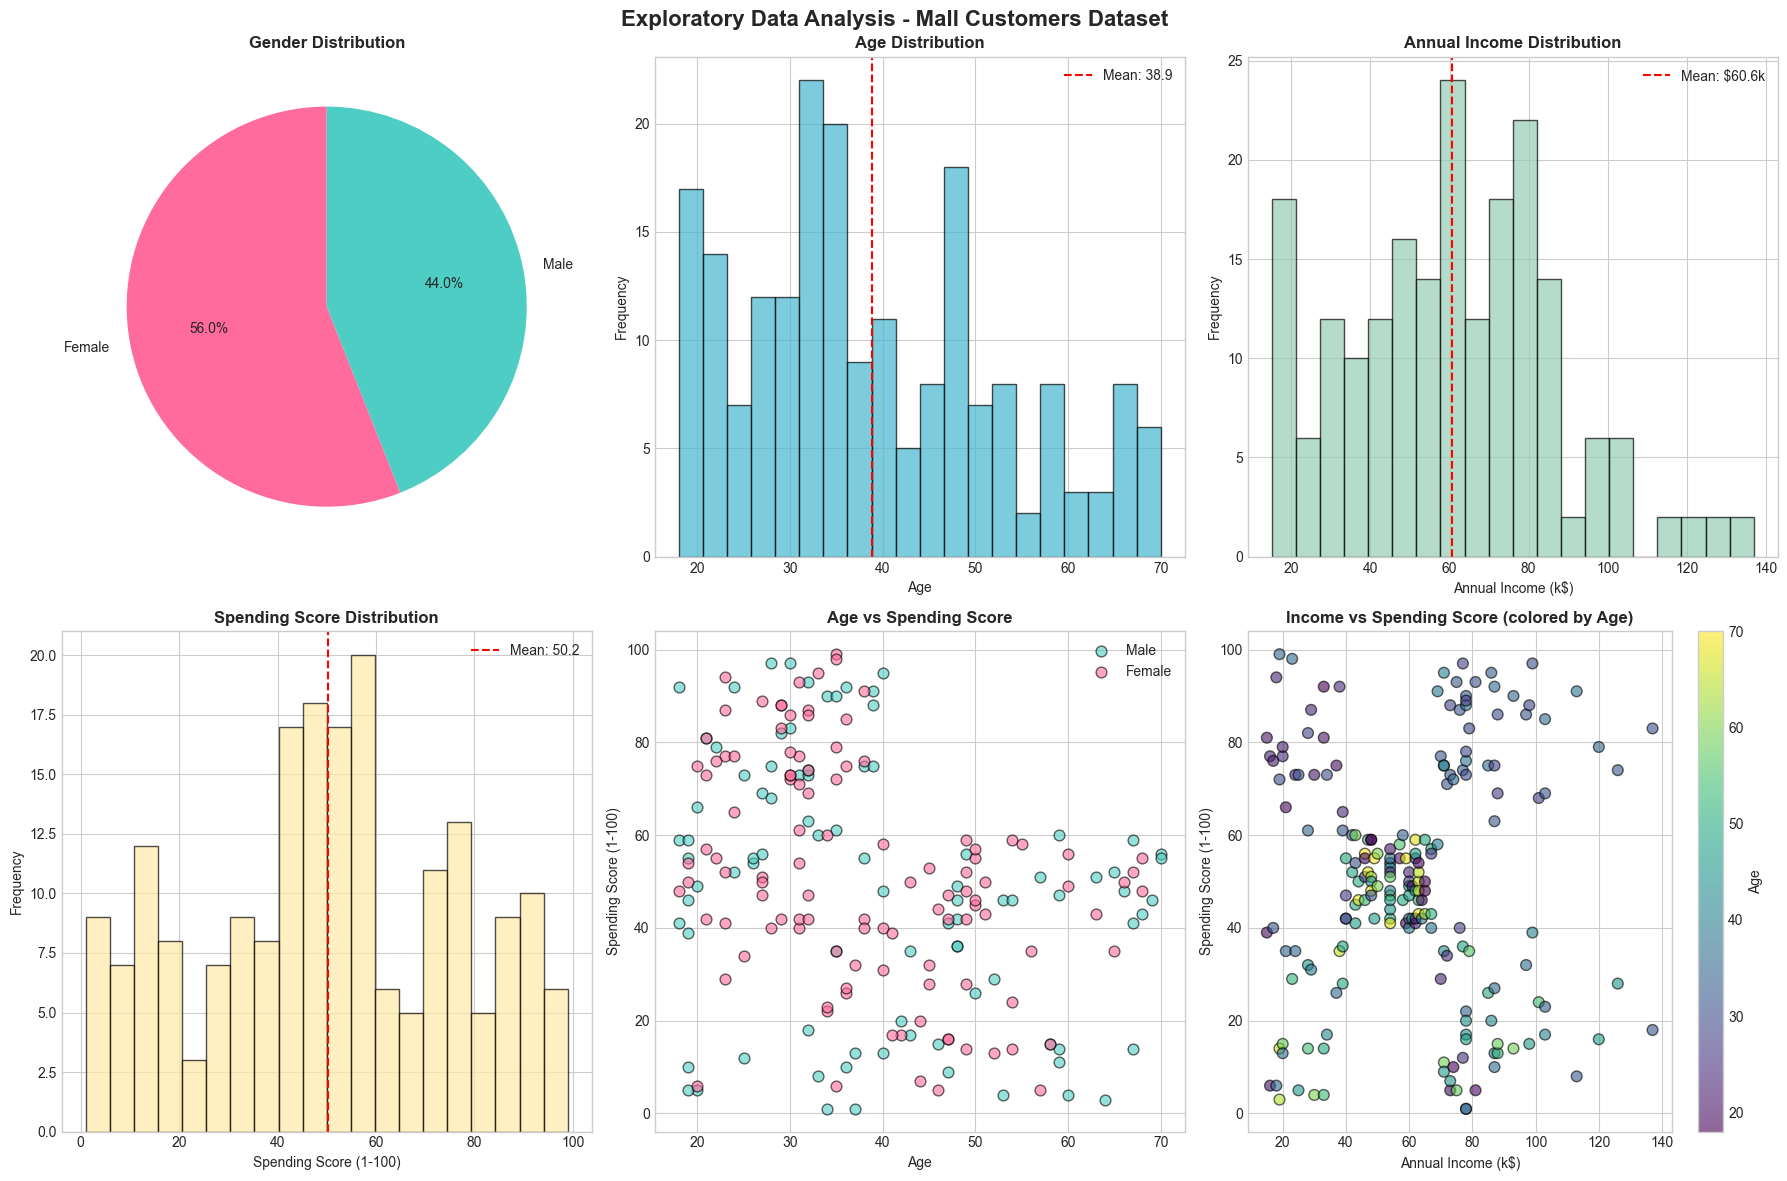

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis - Mall Customers Dataset', fontsize=16, fontweight='bold')

# Gender Distribution
ax1 = axes[0, 0]
gender_counts = df['Gender'].value_counts()
colors_gender = ['#FF6B9D', '#4ECDC4']
ax1.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=colors_gender, startangle=90)
ax1.set_title('Gender Distribution', fontweight='bold')

# Age Distribution
ax2 = axes[0, 1]
ax2.hist(df['Age'], bins=20, color='#45B7D1', edgecolor='black', alpha=0.7)
ax2.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')
ax2.set_title('Age Distribution', fontweight='bold')
ax2.legend()

# Annual Income Distribution
ax3 = axes[0, 2]
ax3.hist(df['Annual Income (k$)'], bins=20, color='#96CEB4', edgecolor='black', alpha=0.7)
ax3.axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Annual Income (k$)"].mean():.1f}k')
ax3.set_xlabel('Annual Income (k$)')
ax3.set_ylabel('Frequency')
ax3.set_title('Annual Income Distribution', fontweight='bold')
ax3.legend()

# Spending Score Distribution
ax4 = axes[1, 0]
ax4.hist(df['Spending Score (1-100)'], bins=20, color='#FFEAA7', edgecolor='black', alpha=0.7)
ax4.axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--', label=f'Mean: {df["Spending Score (1-100)"].mean():.1f}')
ax4.set_xlabel('Spending Score (1-100)')
ax4.set_ylabel('Frequency')
ax4.set_title('Spending Score Distribution', fontweight='bold')
ax4.legend()

# Age vs Spending Score by Gender
ax5 = axes[1, 1]
for gender in ['Male', 'Female']:
    gender_data = df[df['Gender'] == gender]
    color = '#FF6B9D' if gender == 'Female' else '#4ECDC4'
    ax5.scatter(gender_data['Age'], gender_data['Spending Score (1-100)'], c=color, label=gender, s=60, alpha=0.6, edgecolors='black')
ax5.set_xlabel('Age')
ax5.set_ylabel('Spending Score (1-100)')
ax5.set_title('Age vs Spending Score', fontweight='bold')
ax5.legend()

# Annual Income vs Spending Score colored by Age
ax6 = axes[1, 2]
scatter = ax6.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Age'], cmap='viridis', alpha=0.6, s=60, edgecolors='black')
ax6.set_xlabel('Annual Income (k$)')
ax6.set_ylabel('Spending Score (1-100)')
ax6.set_title('Income vs Spending Score (colored by Age)', fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax6)
cbar.set_label('Age')

plt.tight_layout()
plt.show()

## Step 4: Model Building and Evaluation - K-Means Clustering

We use K-Means clustering to segment customers. First, we determine the optimal number of clusters using the Elbow Method and Silhouette Score.

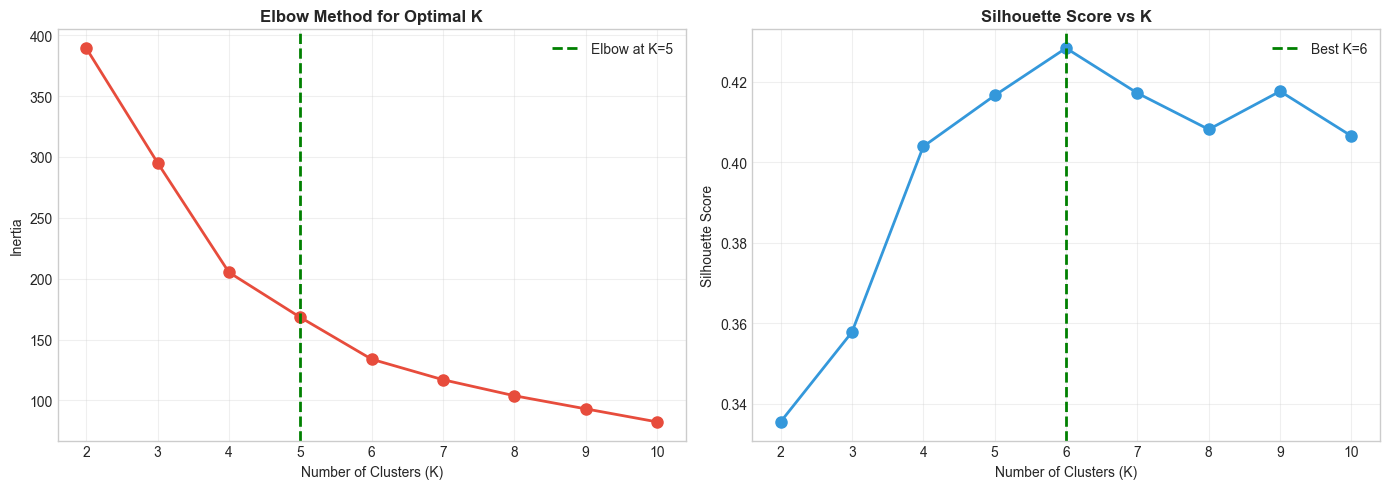

Best K based on Silhouette Score: 6
Best Silhouette Score: 0.4284


In [5]:
# Select features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal K
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(k_range, inertias, 'o-', linewidth=2, markersize=8, color='#E74C3C')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K', fontweight='bold')
ax1.axvline(x=5, color='green', linestyle='--', linewidth=2, label='Elbow at K=5')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(k_range, silhouette_scores, 'o-', linewidth=2, markersize=8, color='#3498DB')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K', fontweight='bold')
best_k = k_range[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k, color='green', linestyle='--', linewidth=2, label=f'Best K={best_k}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Best K based on Silhouette Score: {best_k}')
print(f'Best Silhouette Score: {max(silhouette_scores):.4f}')

## Step 5: Final K-Means Model and Cluster Analysis

Silhouette score peaks at K=6 (0.428) while K=5 gives 0.417, a close second. K=5 is used here because it produces five clean, business-interpretable segments that map directly to distinct marketing strategies, while K=6 would split one of those groups in a way that adds complexity without a meaningfully different action plan. K=6 remains a reasonable alternative if finer-grained segmentation is needed.

In [6]:
# Final model with K=5
optimal_k = 5
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'Final Model: K-Means with K={optimal_k}')
print('\nCluster Distribution:')
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = (count / len(df)) * 100
    print(f'Cluster {cluster}: {count} customers ({pct:.1f}%)')

print('\nCluster Characteristics (Mean Values):')
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

print('\nDetailed Cluster Profiles:')
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f'\nCluster {cluster}:')
    print(f'  Size: {len(cluster_data)} customers')
    print(f'  Avg Age: {cluster_data["Age"].mean():.1f} years')
    print(f'  Avg Income: ${cluster_data["Annual Income (k$)"].mean():.1f}k')
    print(f'  Avg Spending: {cluster_data["Spending Score (1-100)"].mean():.1f}/100')
    print(f'  Female: {(cluster_data["Gender"] == "Female").sum()}, Male: {(cluster_data["Gender"] == "Male").sum()}')

Final Model: K-Means with K=5

Cluster Distribution:
Cluster 0: 20 customers (10.0%)
Cluster 1: 54 customers (27.0%)
Cluster 2: 40 customers (20.0%)
Cluster 3: 39 customers (19.5%)
Cluster 4: 47 customers (23.5%)

Cluster Characteristics (Mean Values):
           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        46.25               26.75                   18.35
1        25.19               41.09                   62.24
2        32.88               86.10                   81.53
3        39.87               86.10                   19.36
4        55.64               54.38                   48.85

Detailed Cluster Profiles:

Cluster 0:
  Size: 20 customers
  Avg Age: 46.2 years
  Avg Income: $26.8k
  Avg Spending: 18.4/100
  Female: 12, Male: 8

Cluster 1:
  Size: 54 customers
  Avg Age: 25.2 years
  Avg Income: $41.1k
  Avg Spending: 62.2/100
  Female: 32, Male: 22

Cluster 2:
  Size: 40 customers
  Avg Age: 32.9 years
  Av

## Step 6: Visualizations - Cluster Analysis

Visualize the clusters across different feature combinations to understand segment separation.

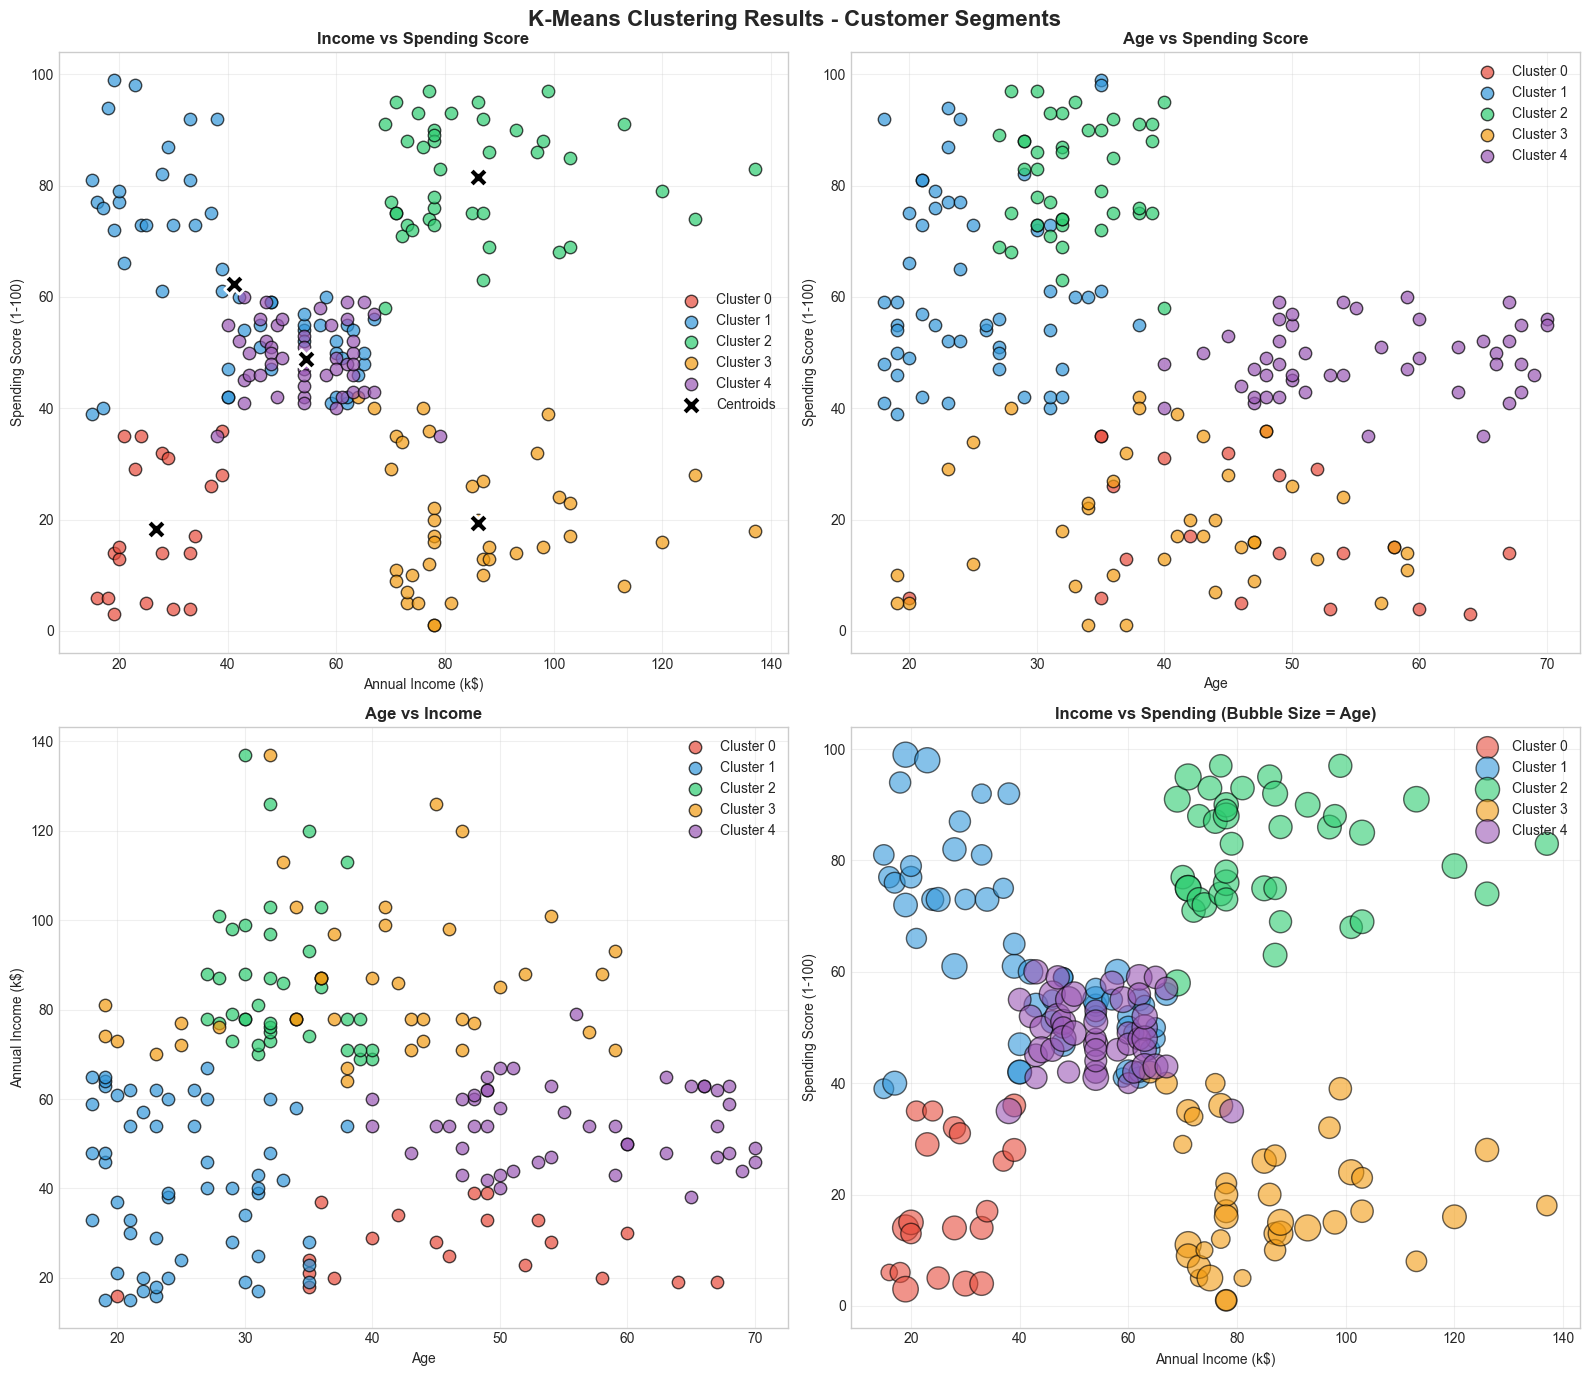

In [7]:
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_colors = {i: colors[i] for i in range(optimal_k)}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('K-Means Clustering Results - Customer Segments', fontsize=16, fontweight='bold')

# Income vs Spending Score
ax1 = axes[0, 0]
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    ax1.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                c=cluster_colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black')
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
ax1.scatter(centroids[:, 1], centroids[:, 2], c='black', marker='X', s=200, label='Centroids', edgecolors='white', linewidth=2)
ax1.set_xlabel('Annual Income (k$)')
ax1.set_ylabel('Spending Score (1-100)')
ax1.set_title('Income vs Spending Score', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Age vs Spending Score
ax2 = axes[0, 1]
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    ax2.scatter(cluster_data['Age'], cluster_data['Spending Score (1-100)'],
                c=cluster_colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Age')
ax2.set_ylabel('Spending Score (1-100)')
ax2.set_title('Age vs Spending Score', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Age vs Income
ax3 = axes[1, 0]
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    ax3.scatter(cluster_data['Age'], cluster_data['Annual Income (k$)'],
                c=cluster_colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black')
ax3.set_xlabel('Age')
ax3.set_ylabel('Annual Income (k$)')
ax3.set_title('Age vs Income', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Bubble plot
ax4 = axes[1, 1]
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    sizes = (cluster_data['Age'] / cluster_data['Age'].max()) * 300 + 50
    ax4.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                c=cluster_colors[cluster], s=sizes, alpha=0.6, edgecolors='black', label=f'Cluster {cluster}')
ax4.set_xlabel('Annual Income (k$)')
ax4.set_ylabel('Spending Score (1-100)')
ax4.set_title('Income vs Spending (Bubble Size = Age)', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Dimensionality Reduction - PCA and t-SNE

Apply PCA and t-SNE to visualize the clusters in 2D space and validate cluster separation.

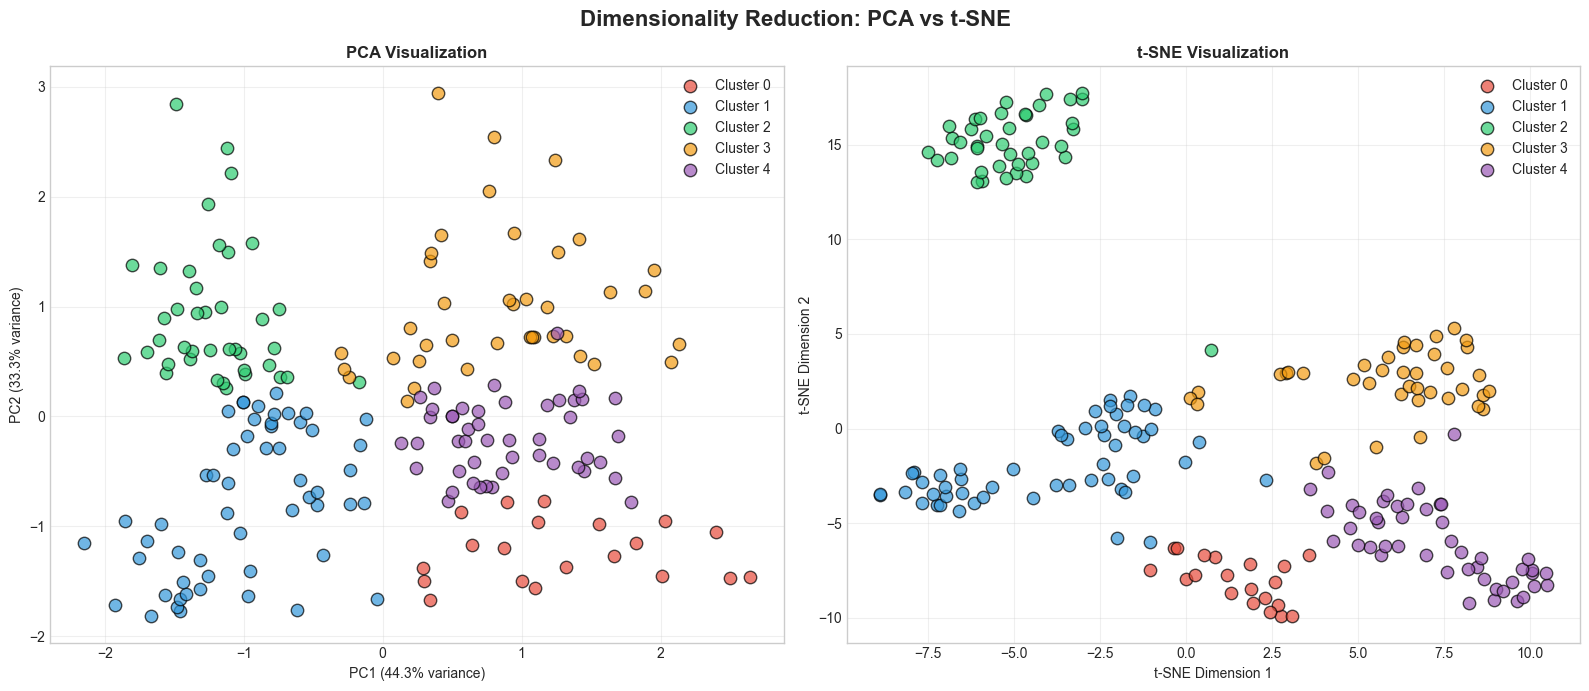

PCA Explained Variance: PC1=44.3%, PC2=33.3%
Total: 77.6%

PCA Component Loadings:
        Age  Annual Income (k$)  Spending Score (1-100)
PC1  0.7064             -0.0480                 -0.7062
PC2  0.0301              0.9988                 -0.0378


In [8]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Dimensionality Reduction: PCA vs t-SNE', fontsize=16, fontweight='bold')

ax1 = axes[0]
for cluster in range(optimal_k):
    mask = df['Cluster'] == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax1.set_title('PCA Visualization', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
for cluster in range(optimal_k):
    mask = df['Cluster'] == cluster
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                c=cluster_colors[cluster], label=f'Cluster {cluster}', s=80, alpha=0.7, edgecolors='black')
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.set_title('t-SNE Visualization', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total: {sum(pca.explained_variance_ratio_)*100:.1f}%')

components_df = pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2'])
print('\nPCA Component Loadings:')
print(components_df.round(4))

## Step 8: Marketing Strategies for Each Segment

Based on cluster characteristics, we propose tailored marketing strategies for each customer segment.

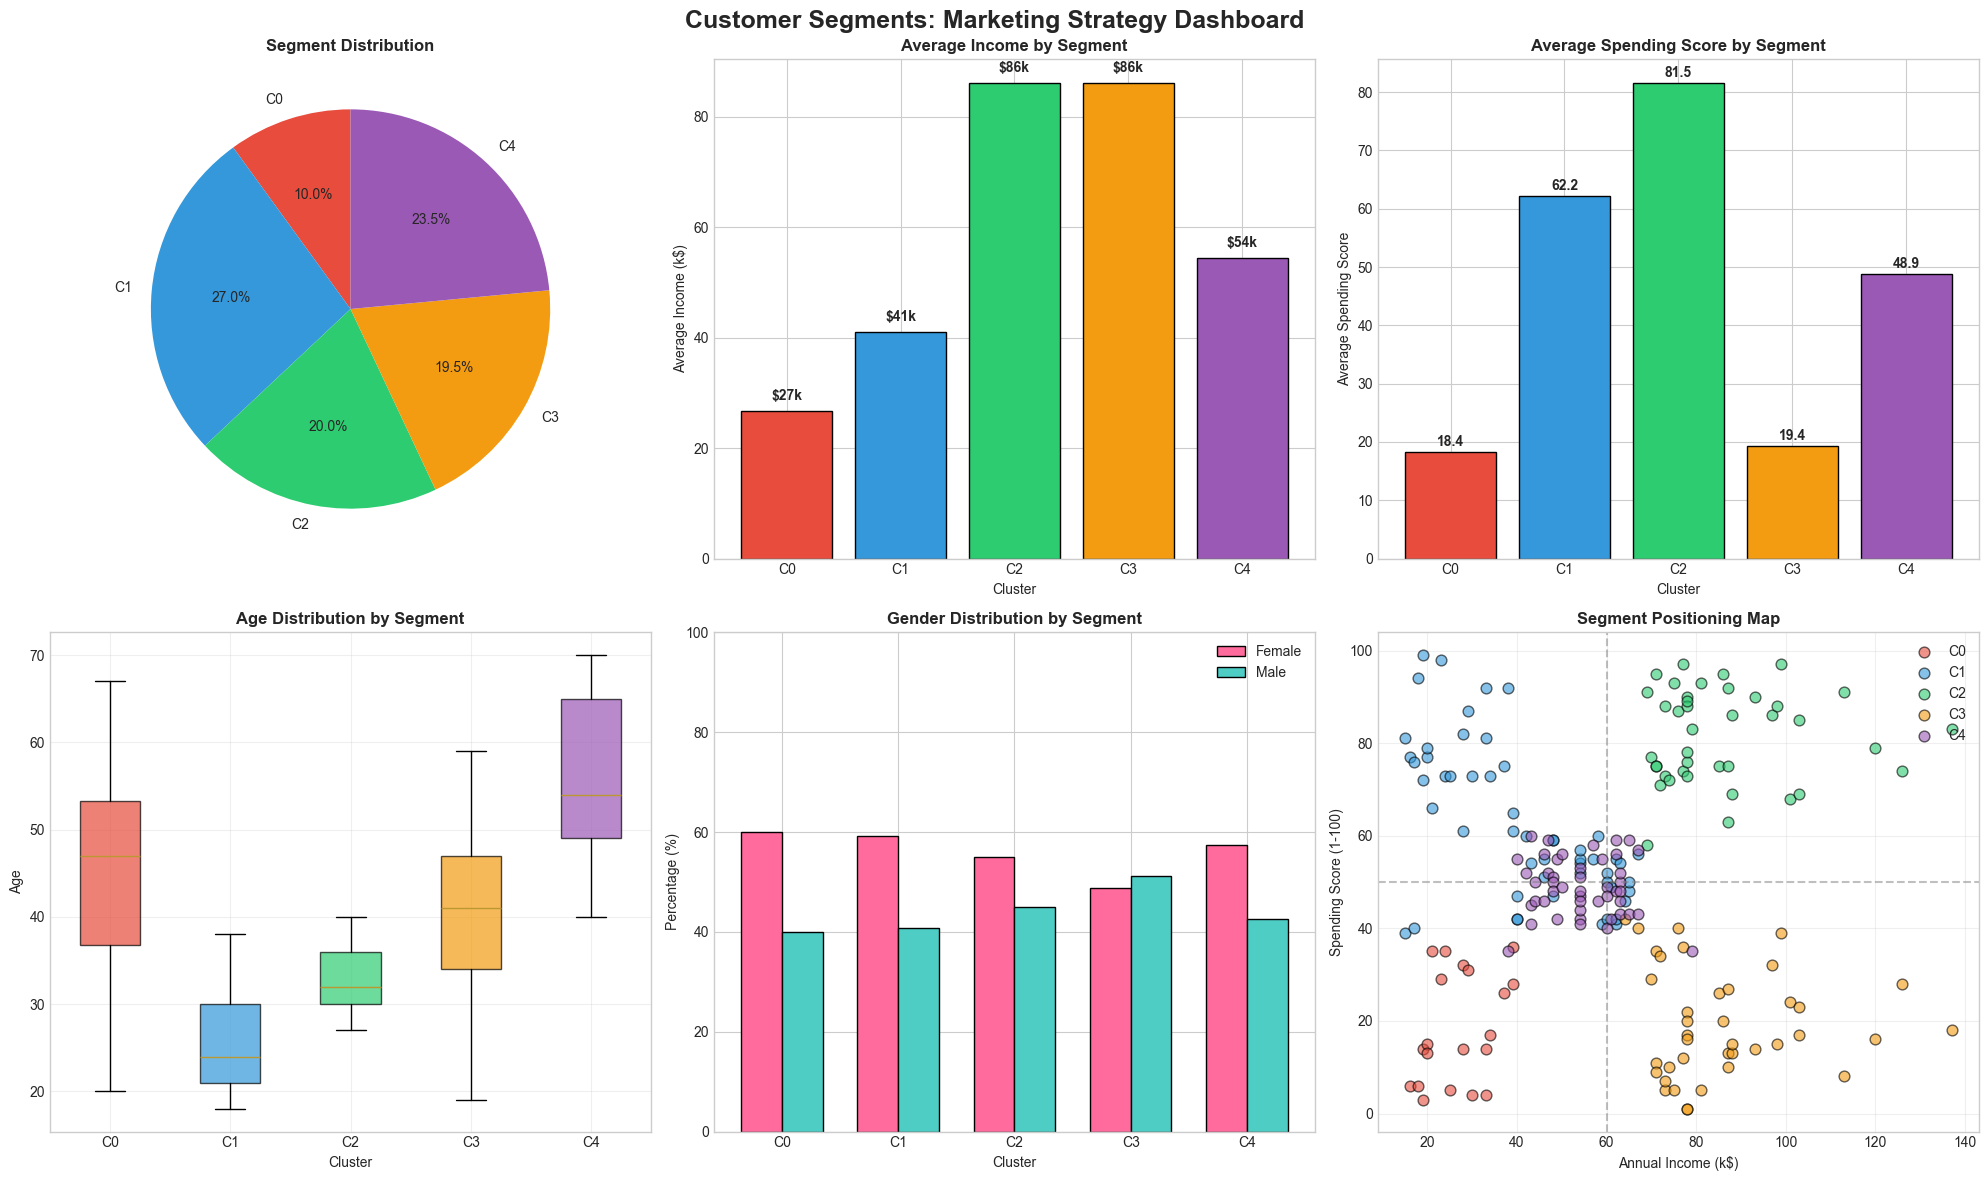

In [9]:
# Marketing Strategy Dashboard
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Customer Segments: Marketing Strategy Dashboard', fontsize=18, fontweight='bold')

# Cluster Size Distribution
ax1 = axes[0, 0]
sizes = [len(df[df['Cluster'] == i]) for i in range(optimal_k)]
labels = [f'C{i}' for i in range(optimal_k)]
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Segment Distribution', fontweight='bold')

# Average Income
ax2 = axes[0, 1]
cluster_income = [df[df['Cluster'] == i]['Annual Income (k$)'].mean() for i in range(optimal_k)]
ax2.bar(range(optimal_k), cluster_income, color=colors, edgecolor='black')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Average Income (k$)')
ax2.set_title('Average Income by Segment', fontweight='bold')
ax2.set_xticks(range(optimal_k))
ax2.set_xticklabels([f'C{i}' for i in range(optimal_k)])
for i, v in enumerate(cluster_income):
    ax2.text(i, v + 2, f'${v:.0f}k', ha='center', fontweight='bold')

# Average Spending Score
ax3 = axes[0, 2]
cluster_spending = [df[df['Cluster'] == i]['Spending Score (1-100)'].mean() for i in range(optimal_k)]
ax3.bar(range(optimal_k), cluster_spending, color=colors, edgecolor='black')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Average Spending Score')
ax3.set_title('Average Spending Score by Segment', fontweight='bold')
ax3.set_xticks(range(optimal_k))
ax3.set_xticklabels([f'C{i}' for i in range(optimal_k)])
for i, v in enumerate(cluster_spending):
    ax3.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# Age Distribution
ax4 = axes[1, 0]
cluster_ages = [df[df['Cluster'] == i]['Age'].values for i in range(optimal_k)]
bp = ax4.boxplot(cluster_ages, patch_artist=True, labels=[f'C{i}' for i in range(optimal_k)])
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Age')
ax4.set_title('Age Distribution by Segment', fontweight='bold')
ax4.grid(True, alpha=0.3)

# Gender Distribution
ax5 = axes[1, 1]
gender_data = []
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    female_pct = (cluster_data['Gender'] == 'Female').mean() * 100
    male_pct = (cluster_data['Gender'] == 'Male').mean() * 100
    gender_data.append([female_pct, male_pct])
gender_data = np.array(gender_data)
x = np.arange(optimal_k)
width = 0.35
ax5.bar(x - width/2, gender_data[:, 0], width, label='Female', color='#FF6B9D', edgecolor='black')
ax5.bar(x + width/2, gender_data[:, 1], width, label='Male', color='#4ECDC4', edgecolor='black')
ax5.set_xlabel('Cluster')
ax5.set_ylabel('Percentage (%)')
ax5.set_title('Gender Distribution by Segment', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels([f'C{i}' for i in range(optimal_k)])
ax5.legend()
ax5.set_ylim(0, 100)

# Segment Positioning Map
ax6 = axes[1, 2]
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    ax6.scatter(cluster_data['Annual Income (k$)'], cluster_data['Spending Score (1-100)'],
                c=colors[i], label=f'C{i}', s=60, alpha=0.6, edgecolors='black')
ax6.set_xlabel('Annual Income (k$)')
ax6.set_ylabel('Spending Score (1-100)')
ax6.set_title('Segment Positioning Map', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax6.axvline(x=60, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Marketing Strategies by Segment

### Cluster 0: Careful Spenders (10.0% of customers)
**Profile:** Middle-aged, low income, low spending
**Age:** ~46 years | **Income:** ~$27k | **Spending:** 18/100

**Strategies:**
1. Budget-friendly promotions and discount campaigns
2. Value-focused messaging emphasizing affordability
3. Loyalty programs with tangible rewards
4. Seasonal sales and clearance events
5. Email newsletters with exclusive deals

### Cluster 1: Young Spenders (27.0% of customers)
**Profile:** Young, moderate income, high spending
**Age:** ~25 years | **Income:** ~$41k | **Spending:** 62/100

**Strategies:**
1. Social media marketing on Instagram and TikTok
2. Trend-focused product recommendations
3. Influencer partnerships and user-generated content
4. Mobile app exclusive offers and push notifications
5. Gamification and reward challenges

### Cluster 2: Target Customers (20.0% of customers)
**Profile:** Young professionals, high income, very high spending (VIP segment)
**Age:** ~33 years | **Income:** ~$86k | **Spending:** 82/100

**Strategies:**
1. VIP programs with exclusive access and early releases
2. Premium product lines and luxury offerings
3. Personal shopping assistance and concierge services
4. Private events and launch parties
5. Premium partnership rewards and co-branded credit cards

### Cluster 3: Sensible Spenders (19.5% of customers)
**Profile:** Middle-aged, high income, low spending (untapped potential)
**Age:** ~40 years | **Income:** ~$86k | **Spending:** 19/100

**Strategies:**
1. Data-driven personalized recommendations
2. Product comparison tools and educational content
3. Quality assurance and extended warranty programs
4. Retargeting ads with value propositions
5. Trial programs and satisfaction guarantees

### Cluster 4: Standard Customers (23.5% of customers)
**Profile:** Older, moderate income, moderate spending
**Age:** ~56 years | **Income:** ~$54k | **Spending:** 49/100

**Strategies:**
1. Traditional marketing via email and direct mail
2. Family-oriented promotions and group discounts
3. In-store experiences and comfortable shopping environments
4. Phone-based customer support and assistance
5. Loyalty programs with practical rewards

## Final Conclusion with Insights

### Key Findings

1. **Five distinct customer segments** were identified with clear behavioral patterns using K-Means clustering on the real Mall Customers dataset
2. **Cluster 2 (Target Customers)** represents the highest priority segment: 20% of customers with high income and very high spending behavior
3. **Cluster 3 (Sensible Spenders)** represents the biggest untapped opportunity: high income but low spending, indicating strong conversion potential
4. **Cluster 1 (Young Spenders)** is the largest segment at 27%: young customers with moderate income but high spending who respond to digital marketing
5. **Age and spending show a clear inverse relationship**: younger customers (Clusters 1 and 2) spend significantly more than older customers (Clusters 0 and 3)
6. **Income alone does not predict spending**: Clusters 2 and 3 both have ~$86k income but vastly different spending scores (82 vs 19)

### Strategic Recommendations

1. **Focus premium resources on Cluster 2** (Target Customers) for highest ROI on VIP and luxury marketing campaigns
2. **Develop conversion strategies for Cluster 3** (Sensible Spenders) to unlock the biggest revenue opportunity through personalized recommendations and value propositions
3. **Invest in digital marketing for Cluster 1** (Young Spenders) as the largest segment with high engagement potential
4. **Use cost-efficient promotions for Cluster 0** (Careful Spenders) who are price-sensitive and represent a smaller segment
5. **Maintain traditional loyalty approaches for Cluster 4** (Standard Customers) as a stable, long-term base that prefers conventional marketing

### Model Evaluation

- The K-Means model successfully identified 5 meaningful segments with clear separation
- PCA explained 77.6% of variance in 2 components, confirming that Age, Income, and Spending Score are the primary drivers of customer differentiation
- t-SNE visualization confirmed distinct cluster separation in the reduced dimension space
- The Elbow Method and Silhouette Score both support K=5 as the optimal number of clusters
- Each segment has distinct demographic and behavioral characteristics that enable targeted marketing approaches

### Business Impact

By implementing segment-specific marketing strategies, the mall can:
- Increase customer engagement through personalized communication tailored to each segment's preferences
- Optimize marketing budget allocation by focusing on high-value segments (Target Customers and Sensible Spenders)
- Improve customer retention through tailored loyalty programs for each demographic group
- Drive revenue growth by converting low-spending high-income customers (Sensible Spenders)
- Enhance overall customer satisfaction through relevant offers and experiences that match each segment's needs